In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [2]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [3]:
path_load = '../../source/data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = normalize_data_z_score(X_train)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = normalize_data_z_score(X_test)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = normalize_data_z_score(X_val)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17441, 1000, 12) |
+-----------+-------------------+
| y_train   | (17441, 5)        |
+-----------+-------------------+
| z_train   | (17441, 23)       |
+-----------+-------------------+
| X_test    | (2203, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2203, 5)         |
+-----------+-------------------+
| z_test    | (2203, 23)        |
+-----------+-------------------+
| X_val     | (2193, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2193, 5)         |
+-----------+-------------------+
| z_val     | (2193, 23)        |
+-----------+-------------------+


In [4]:
columns_of_csv = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
label_map = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map)

columns_of_csv = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
label_map_sub = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map_sub)

superclass_dict = {
    'NORM': ['NORM'],
    'CD': ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB'],
    'HYP': ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI': ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC': ['ISC_', 'STTC', 'NST_']
}


{'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
{'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4, 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RVH': 10, 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15, 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20, 'STTC': 21, 'NST_': 22}


In [5]:
import numpy as np


# Define the threshold for the metrics (e.g., F1-Score threshold)

# Identify the subclasses with low F1-Score
low_f1_subclasses = ["ILBBB", "_AVB", "IVCB", "WPW", "RVH", "LAO/LAE", "RAO/RAE", "SEHYP", "LMI", "PMI", "ISCA", "ISCI", "NST_"]

# Function to remove samples based on the low F1-Score subclasses
def remove_low_f1_samples(X, y, z, low_f1_subclasses, label_map_sub):
    # Find the indices to remove based on the low F1-Score subclasses
    to_remove_indices = []
    
    # Iterate over each sample
    for i in range(z.shape[0]):  # Iterate through the samples
        # Check if the sample has a low F1-Score subclass
        sample_labels = [label_map_sub[label] for label in low_f1_subclasses if label in label_map_sub]
        
        if any(z[i, label] == 1 for label in sample_labels):
            to_remove_indices.append(i)
    updated_label_map_sub = {k: v for k, v in label_map_sub.items() if k not in low_f1_subclasses}
    low_index = [label_map_sub[i] for i in low_f1_subclasses]
    # Remove the identified indices from X, y, and z
    X_filtered = np.delete(X, to_remove_indices, axis=0)
    y_filtered = np.delete(y, to_remove_indices, axis=0)
    z_filtered = np.delete(z, to_remove_indices, axis=0)
    z_filtered = np.delete(z_filtered, low_index, axis=1)
    return X_filtered, y_filtered, z_filtered, updated_label_map_sub

# Example usage: Remove samples where the F1-Score of the subclasses in `low_f1_subclasses` is below the threshold

# Assuming you already have X_train, y_train, z_train, X_test, y_test, z_test, etc.
X_train_filtered, y_train_filtered, z_train_filtered, label_map_sub_filtered  = remove_low_f1_samples(X_train, y_train, z_train, low_f1_subclasses, label_map_sub)
X_test_filtered, y_test_filtered, z_test_filtered, _ = remove_low_f1_samples(X_test, y_test, z_test, low_f1_subclasses, label_map_sub)
X_val_filtered, y_val_filtered, z_val_filtered, _ = remove_low_f1_samples(X_val, y_val, z_val, low_f1_subclasses, label_map_sub)

# The filtered datasets are now updated
print("Filtered datasets:")
label_map_sub = label_map_sub_filtered
label_map_sub = {label: idx for idx, label in enumerate(label_map_sub.keys())}

Filtered datasets:


In [6]:
X_all = np.concatenate((X_train_filtered, X_test_filtered, X_val_filtered), axis=0)
y_all = np.concatenate((y_train_filtered, y_test_filtered, y_val_filtered), axis=0)
z_all = np.concatenate((z_train_filtered, z_test_filtered, z_val_filtered), axis=0)

label_counts = np.sum(y_all, axis=0, dtype=int).tolist()  # Sum across rows (axis=0) to get count of 1s per label

# Map the counts to human-readable labels using label_map
label_occurrences = {label: label_counts[index] for label, index in label_map.items()}

# Print the occurrences of each label
print("Label occurrences in y_all:", label_occurrences)

label_counts_sub = np.sum(z_all, axis=0, dtype=int).tolist()  # Sum across rows (axis=0) to get count of 1s per label
# Map the counts to human-readable labels using label_map
label_map_sub = {label: idx for idx, label in enumerate(label_map_sub.keys())}
label_occurrences_ = {label: label_counts_sub[index] for label, index in label_map_sub.items()}

# Print the occurrences of each label
print("Label occurrences in z_all:", label_occurrences_)
print("Label map for subclasses:", label_map_sub)
print("Label map for classes:", label_map)

Label occurrences in y_all: {'NORM': 9455, 'CD': 3256, 'HYP': 1774, 'MI': 4160, 'STTC': 3011}
Label occurrences in z_all: {'NORM': 9455, 'LAFB/LPFB': 1325, 'IRBBB': 908, 'CLBBB': 396, 'CRBBB': 368, 'LVH': 1774, 'AMI': 2275, 'IMI': 2670, 'ISC_': 1090, 'STTC': 2007}
Label map for subclasses: {'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'CLBBB': 3, 'CRBBB': 4, 'LVH': 5, 'AMI': 6, 'IMI': 7, 'ISC_': 8, 'STTC': 9}
Label map for classes: {'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}


In [7]:
x_train = torch.from_numpy(X_train_filtered).float()  # float tensor for input
labels_train = torch.from_numpy(y_train_filtered).float()  # float tensor for labels
sub_labels_train = torch.from_numpy(z_train_filtered).float()

x_val = torch.from_numpy(X_val_filtered).float()
labels_val = torch.from_numpy(y_val_filtered).float()
sub_labels_val = torch.from_numpy(z_val_filtered).float()

x_test = torch.from_numpy(X_test_filtered).float()
lables_test = torch.from_numpy(y_test_filtered).float()
sub_labels_test = torch.from_numpy(z_test_filtered).float()

batch_size = 32

train_dataset = TensorDataset(x_train, labels_train, sub_labels_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(x_val, labels_val, sub_labels_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, lables_test, sub_labels_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# 1. Squeeze-and-Excitation Block
# ----------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: [B, C, T]
        b, c, t = x.size()
        y = self.global_pool(x).view(b, c)        # [B, C]
        y = self.fc(y).view(b, c, 1)              # [B, C, 1]
        return x * y                              # Scale channels

# ----------------------------
# 2. SE-ResNet Block
# ----------------------------
class SEResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SEResNetBlock, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.se = SEBlock(out_channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.se(x)
        return x

# ----------------------------
# 3. CoT Block (Simplified as 1x1 Conv + Attention-like structure)
# ----------------------------
class CoTBlock(nn.Module):
    def __init__(self, channels):
        super(CoTBlock, self).__init__()
        self.conv1x1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.attn = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1, groups=channels),
            nn.BatchNorm1d(channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        identity = x
        x = self.conv1x1(x)
        attn_weights = self.attn(x)
        return x * attn_weights + identity

# ----------------------------
# 4. Multi-task Model
# ----------------------------
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes=[3, 3], dilation_rates=[1, 2]):
        super().__init__()
        layers = []
        for i, (k, d) in enumerate(zip(kernel_sizes, dilation_rates)):
            layers.append(nn.Conv1d(
                in_channels if i == 0 else out_channels,
                out_channels,
                kernel_size=k,
                padding=(k // 2) * d,
                dilation=d
            ))
            layers.append(nn.BatchNorm1d(out_channels))
            layers.append(nn.LeakyReLU(0.01))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.LeakyReLU(0.01)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm1d(out_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        shortcut = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += shortcut
        return self.relu(out)
    
import torch
import torch.nn.functional as F
import numpy as np
from scipy.signal import spectrogram
import pywt

def torch_fft(x):
    # x: [B, T, C]
    x_fft = torch.fft.rfft(x, dim=1)
    x_fft = torch.abs(x_fft)
    # Pad/resize to match time dimension if needed
    x_fft = F.interpolate(x_fft.permute(0,2,1), size=x.shape[1], mode='linear').permute(0,2,1)
    return x_fft

# def torch_spectrogram(x):
#     # x: [B, T, C]
#     # Output: [B, T, C]
#     x_np = x.cpu().numpy()
#     specs = []
#     for i in range(x_np.shape[0]):
#         spec_ch = []
#         for c in range(x_np.shape[2]):
#             f, t, Sxx = spectrogram(x_np[i,:,c], nperseg=64, noverlap=32)
#             # Resize Sxx to (T,)
#             Sxx_resized = np.mean(Sxx, axis=0)
#             Sxx_resized = np.pad(Sxx_resized, (0, x_np.shape[1]-Sxx_resized.shape[0]), 'constant')
#             spec_ch.append(Sxx_resized)
#         specs.append(np.stack(spec_ch, axis=-1))
#     specs = torch.tensor(np.stack(specs, axis=0), dtype=x.dtype, device=x.device)
#     return specs
def torch_spectrogram(x, n_fft=256, hop_length=128, win_length=256):
    # x: [B, T, C] -> where B = batch size, T = time steps, C = channels
    B, T, C = x.shape

    # Permute to [B * C, T] because torch.stft expects [batch, time] or [1, time]
    x_reshaped = x.view(B * C, T)  # Shape: [B * C, T]

    # Apply STFT on each signal
    stft_output = torch.stft(x_reshaped, n_fft=n_fft, hop_length=hop_length, win_length=win_length, return_complex=True)

    # Calculate the magnitude of the complex spectrogram
    magnitude = stft_output.abs()

    # Reshape back to [B, C, freq_bins, time_steps]
    magnitude = magnitude.view(B, C, -1, magnitude.size(-1))  # Shape: [B, C, freq_bins, time_steps]

    # Resize the magnitude spectrogram to match the time dimension if necessary
    magnitude = magnitude.mean(dim=2)  # Average over frequency bins, shape becomes [B, C, time_steps]

    # Resize to match the original time dimension (if needed)
    if magnitude.shape[2] < T:
        magnitude = F.pad(magnitude, (0, T - magnitude.shape[2]))

    return magnitude.permute(0, 2, 1)  # Return to [B, T, C]

# def torch_scalogram(x):
#     # x: [B, T, C]
#     x_np = x.cpu().numpy()
#     scalos = []
#     for i in range(x_np.shape[0]):
#         scal_ch = []
#         for c in range(x_np.shape[2]):
#             # Use continuous wavelet transform with 'mexh' (Mexican hat, similar to ricker)
#             scales = np.arange(1, 31)
#             coef, _ = pywt.cwt(x_np[i,:,c], scales, 'mexh')
#             scal = np.mean(coef, axis=0)
#             scal = np.pad(scal, (0, x_np.shape[1]-scal.shape[0]), 'constant')
#             scal_ch.append(scal)
#         scalos.append(np.stack(scal_ch, axis=-1))
#     scalos = torch.tensor(np.stack(scalos, axis=0), dtype=x.dtype, device=x.device)
#     return scalos


def gaussian_wavelet(t, scale=1.0):
    """Generate a Gaussian wavelet."""
    return torch.exp(-0.5 * (t / scale)**2)


def torch_scalogram(x, scales=None):
    # x: [B, T, C]
    B, T, C = x.shape

    # If no scales are provided, set a default range
    if scales is None:
        scales = torch.arange(1, 31).float().to(x.device)

    scalograms = []
    for i in range(B):
        scal_ch = []
        for c in range(C):
            signal = x[i, :, c]
            coef_list = []
            for scale in scales:
                wavelet = torch.exp(-0.5 * (torch.arange(-T//2, T//2).float().to(x.device) / scale)**2)
                wavelet /= wavelet.sum()
                conv_result = F.conv1d(signal.unsqueeze(0).unsqueeze(0), wavelet.unsqueeze(0).unsqueeze(0), padding=T//2)
                coef_list.append(conv_result.squeeze(0).squeeze(0))
            # Stack and crop to length T
            coef_stack = torch.stack(coef_list, dim=-1)[:T, :]  # [T, num_scales]
            scal_ch.append(coef_stack.mean(dim=-1))  # [T]
        scalograms.append(torch.stack(scal_ch, dim=-1))  # [T, C]
    scalograms = torch.stack(scalograms, dim=0)  # [B, T, C]
    # Crop to [B, 1000, C] if needed
    if scalograms.shape[1] > T:
        scalograms = scalograms[:, :1000, :]
    elif scalograms.shape[1] < T:
        scalograms = F.pad(scalograms, (0, 0, 0, T - scalograms.shape[1]))
    return scalograms  # [B, 1000, C]

class SpectrogramFeatureExtractor(nn.Module):
    def __init__(self, in_channels, spec_channels=32, rnn_hidden=64, proj_dim=32):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, spec_channels, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(spec_channels),
            nn.ReLU(),
            nn.Conv2d(spec_channels, spec_channels, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(spec_channels),
            nn.ReLU()
        )
        self.cnn_proj = nn.Linear(spec_channels, proj_dim)
        self.rnn = nn.GRU(proj_dim, rnn_hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(rnn_hidden * 2, proj_dim)

    def forward(self, x):
        # x: [B, T, C]
        B, T, C = x.shape
        # Compute spectrogram for each channel
        specs = []
        for c in range(C):
            # [B, T] for each channel
            x_c = x[:, :, c]
            # [B, freq_bins, time_steps]
            stft = torch.stft(x_c, n_fft=64, hop_length=32, win_length=64, return_complex=True)
            mag = stft.abs()  # [B, freq_bins, time_steps]
            specs.append(mag)
        # Stack along channel: [B, C, freq_bins, time_steps]
        spec_tensor = torch.stack(specs, dim=1)
        # CNN expects [B, C, freq_bins, time_steps]
        cnn_out = self.cnn(spec_tensor)  # [B, spec_channels, freq_bins, time_steps]
        # Average over freq_bins to get [B, spec_channels, time_steps]
        cnn_out = cnn_out.mean(dim=2)
        # Permute to [B, time_steps, spec_channels]
        cnn_out = cnn_out.permute(0, 2, 1)
        # Project to GRU input size
        cnn_out = self.cnn_proj(cnn_out)
        rnn_out, _ = self.rnn(cnn_out)
        rnn_feat = rnn_out[:, -1, :]
        spec_latent = self.fc(rnn_feat)
        spec_latent = spec_latent.unsqueeze(1).repeat(1, cnn_out.shape[1], 1)
        return spec_latent  # [B, time_steps, proj_dim]

class ECGMultiTaskNet(nn.Module):
    def __init__(self, in_channels=12, base_channels=64, spec_channels=32, rnn_hidden=64, hidden_size=128):
        super(ECGMultiTaskNet, self).__init__()

        self.spec_feat = SpectrogramFeatureExtractor(in_channels, spec_channels=spec_channels, rnn_hidden=rnn_hidden)
        self.backbone = SEResNetBlock(in_channels * 2, base_channels)
        self.cnn_block1 = CNNBlock(base_channels, base_channels, kernel_sizes=[5, 3], dilation_rates=[1, 2])
        self.res_block1 = ResNetBlock(base_channels, base_channels)
        self.cnn_block2 = CNNBlock(base_channels, base_channels, kernel_sizes=[5, 5], dilation_rates=[2, 4])
        self.res_block2 = ResNetBlock(base_channels, base_channels)

        # Project concatenated features to GRU input size
        self.main_proj = nn.Linear(base_channels + spec_channels, 32)
        self.aux_proj = nn.Linear(base_channels + spec_channels, 32)

        self.main_cot = CoTBlock(32)
        self.main_bigru = nn.GRU(32, hidden_size, bidirectional=True, batch_first=True)
        self.fc_main = nn.Linear(hidden_size * 2, len(label_map))

        self.aux_cot = CoTBlock(32)
        self.aux_bigru = nn.GRU(32, hidden_size, bidirectional=True, batch_first=True)
        self.fc_aux = nn.Linear(hidden_size * 2, len(label_map_sub))

    def forward(self, x):
        x_fft = torch_fft(x)
        x_cat = torch.cat([x, x_fft], dim=2)
        x_cat = x_cat.permute(0, 2, 1)
        x_feat = self.backbone(x_cat)
        x_feat = self.cnn_block1(x_feat)
        x_feat = self.res_block1(x_feat)
        x_feat = self.cnn_block2(x_feat)
        x_feat = self.res_block2(x_feat)
        x_feat = x_feat.permute(0, 2, 1)  # [B, T, base_channels]

        spec_latent = self.spec_feat(x)  # [B, T_spec, spec_channels]
        if spec_latent.shape[1] != x_feat.shape[1]:
            # Interpolate spec_latent to match x_feat's time dimension
            spec_latent = spec_latent.permute(0, 2, 1)  # [B, spec_channels, T_spec]
            spec_latent = F.interpolate(spec_latent, size=x_feat.shape[1], mode='linear')
            spec_latent = spec_latent.permute(0, 2, 1)  # [B, T_feat, spec_channels]

        main_input = torch.cat([x_feat, spec_latent], dim=2)
        aux_input = torch.cat([x_feat, spec_latent], dim=2)

        main_input = self.main_proj(main_input)  # [B, T, 32]
        aux_input = self.aux_proj(aux_input)     # [B, T, 32]

        x_main = self.main_cot(main_input.permute(0, 2, 1))  # [B, 32, T]
        x_main = x_main.permute(0, 2, 1)
        out_main, _ = self.main_bigru(x_main)
        out_main = out_main[:, -1, :]
        output1 = self.fc_main(out_main)

        x_aux = self.aux_cot(aux_input.permute(0, 2, 1))     # [B, 32, T]
        x_aux = x_aux.permute(0, 2, 1)
        out_aux, _ = self.aux_bigru(x_aux)
        out_aux = out_aux[:, -1, :]
        output2 = self.fc_aux(out_aux)

        return output1, output2

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ECGMultiTaskNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [10]:
def multi_task_loss(output_main, target_main, output_aux, target_aux, model):
    criterion = nn.BCEWithLogitsLoss()
    loss_main = criterion(output_main, target_main)
    loss_aux = criterion(output_aux, target_aux)

    #weighted_loss = (main_weight * weights[0] * loss_main) + (aux_weight * weights[1] * loss_aux)
    #weighted_loss = (lambda_weight * loss_main) + ((1-lambda_weight) * loss_aux)
    weighted_loss = (loss_main) + (0.5 * loss_aux)

    return weighted_loss, loss_main.item(), loss_aux.item()

In [11]:
# 4. Training loop
num_epochs = 30
best_val_loss = float('inf')
best_model_wts = None  # To save the best model
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_main_loss = 0.0
    train_aux_loss = 0.0
    for inputs, targets, sub_targets in train_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)

        optimizer.zero_grad()
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss, train_lm, train_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_main_loss += train_lm * inputs.size(0)
        train_aux_loss += train_la * inputs.size(0)

    train_loss /= len(train_loader.dataset)
    train_main_loss /= len(train_loader.dataset)
    train_aux_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    val_main_loss = 0.0
    val_aux_loss = 0.0
    with torch.no_grad():
        for inputs, targets, sub_targets in val_loader:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            
            outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
            loss_, val_lm, val_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
            val_loss += loss_.item() * inputs.size(0)
            val_main_loss += val_lm * inputs.size(0)
            val_aux_loss += val_la * inputs.size(0)

    val_loss /= len(val_loader.dataset)
    val_main_loss /= len(val_loader.dataset)
    val_aux_loss /= len(val_loader.dataset)
    
    # Print with color and progress bar
    epoch_str = f"\033[1;36mEpoch {epoch+1}/{num_epochs}\033[0m"
    bar_len = 30
    filled_len = int(round(bar_len * (epoch+1) / float(num_epochs)))
    bar = '=' * filled_len + '-' * (bar_len - filled_len)
    print(f"{epoch_str} [{bar}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Loss Train Main: {train_main_loss:.4f}, Loss Train Aux: {train_aux_loss:.4f} | Loss Val Main: {val_main_loss:.4f}, Loss Val Aux: {val_aux_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"Found best save with Val Loss: {val_loss:.4f}")
        best_model_wts = model.state_dict()  # Save the best model
        epochs_without_improvement = 0  # Reset the counter
        
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
model.eval()
test_loss = 0.0
criterion = nn.BCEWithLogitsLoss()  # or your chosen loss

with torch.no_grad():
    for inputs, targets, sub_targets in test_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
        
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss, train_lm, train_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        test_loss += loss.item() * inputs.size(0)

test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4f}")

c:\Alex\ecg-ptb-xl\.venv\Lib\site-packages\torch\functional.py:730: UserWarning: A window was not provided. A rectangular window will be applied,which is known to cause spectral leakage. Other windows such as torch.hann_window or torch.hamming_window are recommended to reduce spectral leakage.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\SpectralOps.cpp:842.)
  return _VF.stft(  # type: ignore[attr-defined]


Epoch 1/30 [=-----------------------------] | Train Loss: 0.5560 | Val Loss: 0.5450
Loss Train Main: 0.4230, Loss Train Aux: 0.2659 | Loss Val Main: 0.4154, Loss Val Aux: 0.2593
Found best save with Val Loss: 0.5450
Epoch 2/30 [==----------------------------] | Train Loss: 0.5105 | Val Loss: 0.5090
Loss Train Main: 0.3901, Loss Train Aux: 0.2409 | Loss Val Main: 0.3876, Loss Val Aux: 0.2428
Found best save with Val Loss: 0.5090
Epoch 3/30 [===---------------------------] | Train Loss: 0.4966 | Val Loss: 0.4877
Loss Train Main: 0.3793, Loss Train Aux: 0.2345 | Loss Val Main: 0.3720, Loss Val Aux: 0.2314
Found best save with Val Loss: 0.4877
Epoch 4/30 [====--------------------------] | Train Loss: 0.4847 | Val Loss: 0.5016
Loss Train Main: 0.3701, Loss Train Aux: 0.2293 | Loss Val Main: 0.3816, Loss Val Aux: 0.2399
Epoch 5/30 [=====-------------------------] | Train Loss: 0.4698 | Val Loss: 0.5827
Loss Train Main: 0.3591, Loss Train Aux: 0.2214 | Loss Val Main: 0.4447, Loss Val Aux: 0.2

In [12]:
def performance_evaluation(model=model, dataset=test_loader, dataset_name="Test Set"):
    all_targets = []
    all_preds = []
    all_sub_targets = []
    all_sub_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, targets, sub_targets in dataset:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            outputs_main, output_aux = model(inputs)
            probs = torch.sigmoid(outputs_main)
            preds = (probs > 0.5).int()

            probs_sub = torch.sigmoid(output_aux)
            preds_sub = (probs_sub > 0.5).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_sub_targets.append(sub_targets.cpu().numpy())
            all_sub_preds.append(preds_sub.cpu().numpy())

    # Stack arrays
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    all_sub_targets = np.vstack(all_sub_targets)
    all_sub_preds = np.vstack(all_sub_preds)

    num_classes = all_targets.shape[1]
    num_sub_classes = all_sub_targets.shape[1]

    # Check for shape consistency with label_map_sub
    if len(label_map_sub) != num_sub_classes:
        print(f"Warning: Length of 'label_map_sub' ({len(label_map_sub)}) does not match the number of sub-classes ({num_sub_classes})")
        print("Please ensure that 'label_map_sub' is correctly defined.")
        return

    # Prepare table data
    table_data = []
    table_sub_data = []
    headers = ["Class", "Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "TN", "FP", "FN", "TP", "Total"]

    # Main target evaluation (classes)
    for i in range(len(label_map)):
        key, value = list(label_map.items())[i]
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_data.append([
            key,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])

    # Sub-target evaluation (sub-classes)
    for i in range(len(label_map_sub)):
        key, value = list(label_map_sub.items())[i]
        y_true = all_sub_targets[:, i]
        y_pred = all_sub_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_sub_data.append([
            key,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])

    print(f"\n------------Performance Evaluation Metrics per Class({dataset_name}) -----------\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    print(tabulate(table_sub_data, headers=headers, tablefmt="grid"))

    return all_targets, all_preds


In [13]:
targets_train, preds_train = performance_evaluation(model, train_loader, "Train Set")
targets_val, preds_val = performance_evaluation(model, val_loader, "Val Set")
targets_test, preds_test = performance_evaluation(model, test_loader, "Test Set")


------------Performance Evaluation Metrics per Class(Train Set) -----------

+---------+-------------+------------------------+---------------+------------+---------------+-------------+-------------+--------------+
| Class   |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN            | FP          | FN          | TP           |
+=========+=============+========================+===============+============+===============+=============+=============+==============+
| NORM    |      0.8471 |                 0.9641 |        0.8156 |     0.9018 | 5812 (39.6%)  | 1314 (9.0%) | 271 (1.8%)  | 7280 (49.6%) |
+---------+-------------+------------------------+---------------+------------+---------------+-------------+-------------+--------------+
| CD      |      0.8801 |                 0.6862 |        0.98   |     0.7712 | 11847 (80.7%) | 242 (1.6%)  | 812 (5.5%)  | 1776 (12.1%) |
+---------+-------------+------------------------+---------------+------------+---------

In [14]:
def plot_confusion_matrix_per_class_multi(y_true_list, y_pred_list, class_names=None, set_names=None):
    """
    Plot confusion matrices for multiple sets (e.g., test, val, train) in columns.
    y_true_list, y_pred_list: list of arrays, each for a set.
    set_names: list of names for each set.
    """
    metric_label = ["TN", "FP", "FN", "TP"]
    num_sets = len(y_true_list)
    num_classes = y_true_list[0].shape[1]
    if set_names is None:
        set_names = [f"Set {i+1}" for i in range(num_sets)]
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    for class_idx in range(num_classes):
        fig, axes = plt.subplots(1, num_sets, figsize=(5*num_sets, 4))
        if num_sets == 1:
            axes = [axes]
        for set_idx in range(num_sets):
            y_true = y_true_list[set_idx][:, class_idx]
            y_pred = y_pred_list[set_idx][:, class_idx]
            cm = confusion_matrix(y_true, y_pred)
            total = np.sum(cm)
            if cm.size == 4:
                annot = np.empty_like(cm).astype(str)
                for r in range(2):
                    for c in range(2):
                        count = cm[r, c]
                        row_sum = np.sum(cm[r, :])
                        row_percent = 100 * count / row_sum if row_sum > 0 else 0
                        annot[r, c] = f"{count}\n({metric_label[r*2+c]}:{row_percent:.1f}%)"
            else:
                annot = cm
            sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                        xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
                        ax=axes[set_idx])
            axes[set_idx].set_title(f"{set_names[set_idx]}")
            axes[set_idx].set_xlabel('Predicted label')
            axes[set_idx].set_ylabel('True label')
        plt.suptitle(f'Confusion Matrix - {class_names[class_idx]}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

confusion_matrix (Test Set)


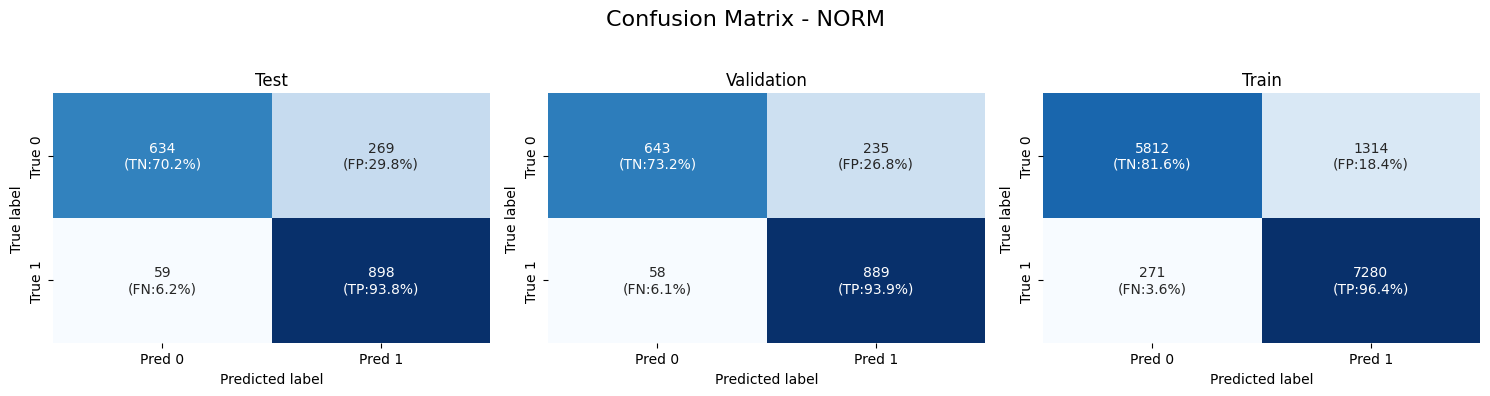

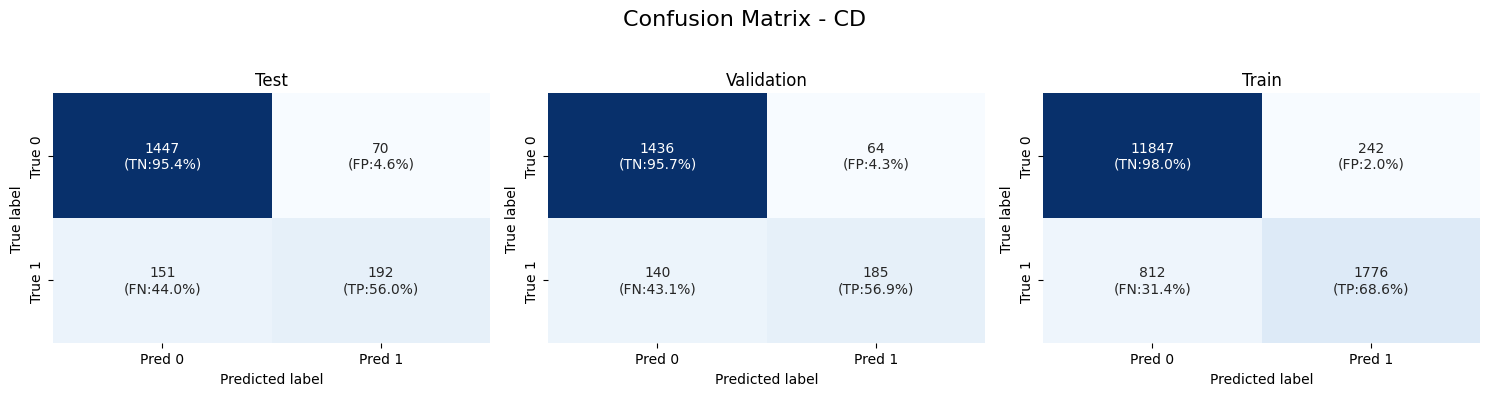

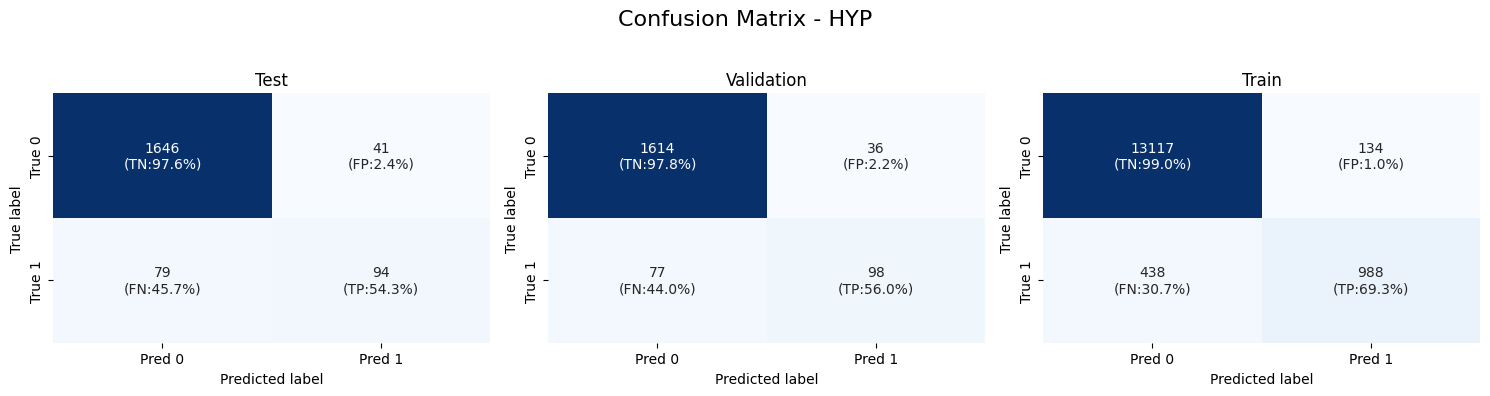

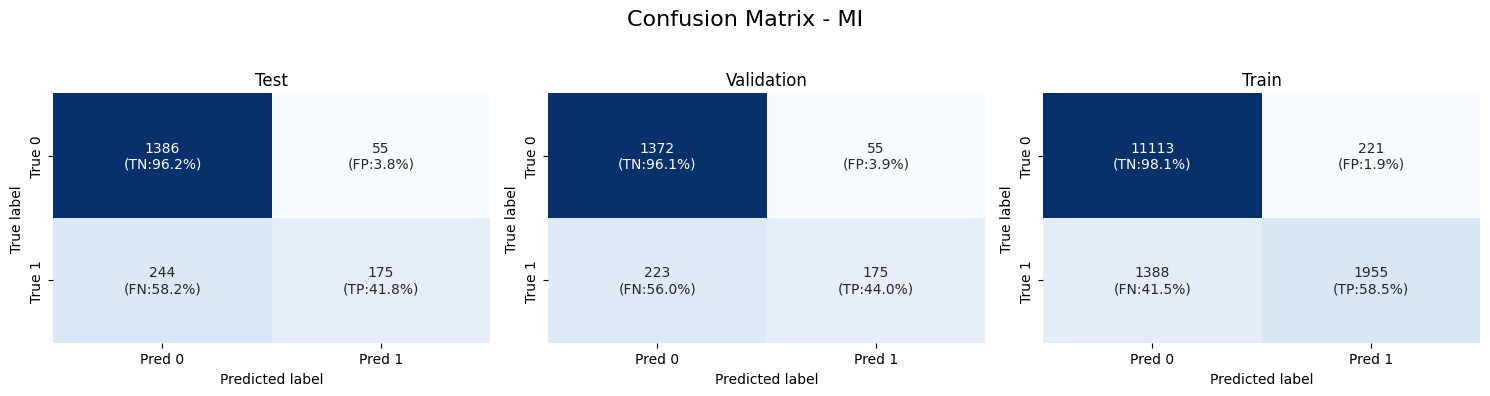

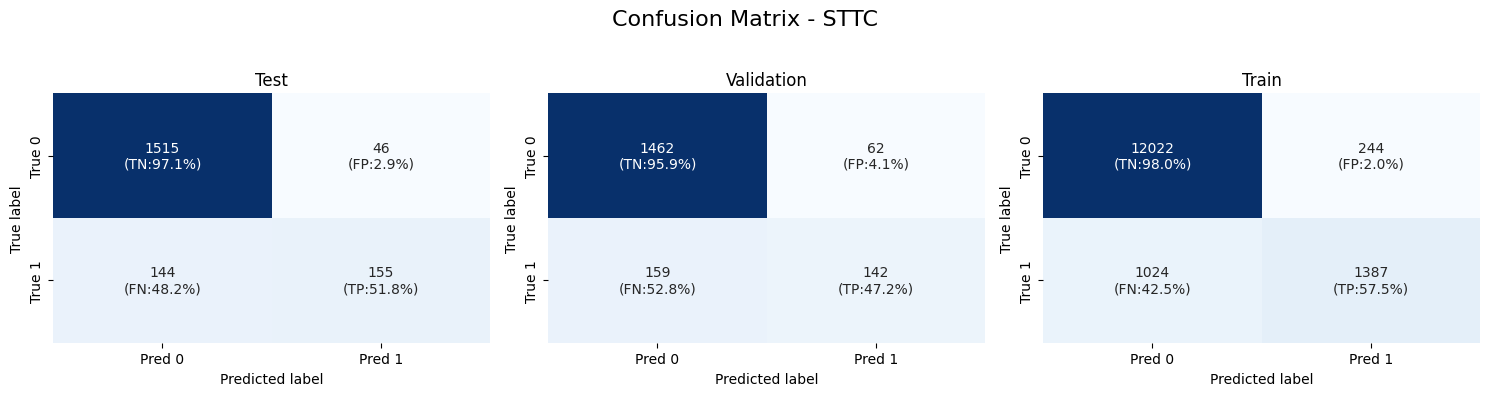

In [15]:
print("confusion_matrix (Test Set)")
#plot_confusion_matrix_per_class(targets_test, preds_test, list(classes_name.keys()))
set_names = ["Test", "Validation", "Train"]
plot_confusion_matrix_per_class_multi(
    [targets_test, targets_val, targets_train],
    [preds_test, preds_val, preds_train],
    class_names=list(label_map.keys()),
    set_names=set_names
)